# Tarea 2:  Health Landscape – ENO + GRD

- **Integrantes:** Ignacio Corvalán y Valentina Cornejo
- **Profesor:** Leo Ferres
- **Ayudante:** Antuan Vayisqui
- **Región asignada:** Región Metropolitana
- **Comuna asignada:** La Florida
- **Código comuna:** 13110

En esta tarea se construye un panorama de salud de la comuna de La Florida utilizando los datasets ENO y GRD. Además, se reutilizan indicadores demográficos obtenidos en la Tarea 1, especialmente la población total y el porcentaje de población extranjera, para calcular tasas y contextualizar los resultados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import geopandas as gpd

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

<Figure size 800x500 with 0 Axes>

En esta sección se importan las librerías necesarias para cargar, limpiar, analizar y visualizar los datos.

In [2]:
MY_COMUNAS = [13110]

t1_summary = pd.DataFrame({
    "codigo_comuna": [13110],
    "nombre_comuna": ["La Florida"],
    "pop_total": [374836],
    "pop_foreign": [36685],
    "pct_foreign": [9.79]
})

t1_summary["codigo_comuna"] = t1_summary["codigo_comuna"].astype(str)
t1_summary["nombre_comuna_upper"] = t1_summary["nombre_comuna"].str.upper()

t1_summary

,codigo_comuna,nombre_comuna,pop_total,pop_foreign,pct_foreign,nombre_comuna_upper
0,13110,La Florida,374836,36685,9.79,LA FLORIDA


La tabla anterior resume la información demográfica obtenida en la Tarea 1 para la comuna de La Florida. Esta información se utilizará como base para calcular tasas por 10.000 habitantes y para contextualizar la participación de población extranjera en los análisis de ENO y GRD.

## Parte A: ENO – Carga y limpieza de datos

En esta sección se carga la base ENO, se seleccionan solo las variables necesarias y se filtran los registros correspondientes a la comuna de La Florida.

In [3]:
eno_cols = [
    "ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
    "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
    "cie_10_diagnostico", "diagnostico", "pais_contagio"
]

eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

print("Shape ENO:", eno.shape)
eno.info()

Shape ENO: (333300, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


In [4]:
eno["codigo_comuna_residencia"] = eno["codigo_comuna_residencia"].astype(str)

anon_rows = (eno["codigo_comuna_residencia"] == "*****").sum()
print("Filas anonimizadas en ENO:", anon_rows)

eno_com = eno[eno["codigo_comuna_residencia"].isin(["13110"])].copy()
print("Filas de La Florida:", len(eno_com))

Filas anonimizadas en ENO: 148217
Filas de La Florida: 2128


Se filtró la base ENO para trabajar únicamente con la comuna de **La Florida** (`13110`). Como resultado, se obtuvieron **2.128 registros** correspondientes a esta comuna.

In [5]:
nat_dist = eno_com["nacionalidad"].value_counts(dropna=False).reset_index()
nat_dist.columns = ["nacionalidad", "cantidad"]
nat_dist["porcentaje"] = nat_dist["cantidad"] / nat_dist["cantidad"].sum() * 100
nat_dist

,nacionalidad,cantidad,porcentaje
0,Chile,1539,72.321429
1,Extranjero,342,16.071429
2,Desconocido,247,11.607143


In [6]:
eno_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

dropped_nat = len(eno_com) - len(eno_nat)
pct_dropped = dropped_nat / len(eno_com) * 100 if len(eno_com) > 0 else 0

print("Filas excluidas por nacionalidad desconocida:", dropped_nat)
print("Porcentaje excluido:", round(pct_dropped, 2), "%")

Filas excluidas por nacionalidad desconocida: 247
Porcentaje excluido: 11.61 %


En la comuna de La Florida, la mayoría de las notificaciones ENO corresponde a personas de nacionalidad chilena (**1.539 casos; 72,32%**), seguida por personas extranjeras (**342 casos; 16,07%**). Además, se registran 247 casos con nacionalidad desconocida (**11,61%**).

Para realizar comparaciones por nacionalidad, se excluyeron los registros clasificados como Desconocido, lo que implicó eliminar **247 observaciones**, equivalentes al **11,61%** del total. Esta exclusión permite un análisis más claro entre población chilena y extranjera, aunque reduce parcialmente la cobertura de los datos.


In [7]:
print("Año mínimo:", eno_com["anho_notificacion"].min())
print("Año máximo:", eno_com["anho_notificacion"].max())

eno_year = (
    eno_com.groupby("anho_notificacion")
    .size()
    .reset_index(name="notificaciones")
    .sort_values("anho_notificacion")
)

eno_year

Año mínimo: 2007
Año máximo: 2024


,anho_notificacion,notificaciones
0,2007,34
1,2008,44
2,2009,58
3,2010,77
4,2011,70
5,2012,64
6,2013,90
7,2014,82
8,2015,99
9,2016,94


La base filtrada para la comuna de La Florida contiene registros desde el año 2007 hasta el año 2024 lo que nos permite tener una amplia visión de datos.

En términos generales, durante los primeros años se observa un volumen relativamente bajo de notificaciones, con cifras que se mueven entre **34 y 101 casos anuales** entre 2007 y 2018. Posteriormente, se aprecia un aumento importante en **2019**, año en que las notificaciones suben a **224 casos**.

Luego, en **2020** y **2021**, los registros vuelven a bajar a **99** y **98 casos**, respectivamente. Más adelante, se observa un nuevo incremento en **2022** (**149 casos**) y, sobre todo, en **2023**, que presenta el valor más alto de toda la serie con **425 notificaciones**. Finalmente, en **2024** se registran **232 casos**, cifra menor a la del año anterior, pero aún superior a la mayoría de los años previos.

Estos resultados muestran que las notificaciones ENO en La Florida no siguen una tendencia completamente estable, sino que presentan variaciones importantes en el tiempo. Estas diferencias pueden reflejar cambios en la situación epidemiológica, en los sistemas de vigilancia o en la intensidad del registro de casos.

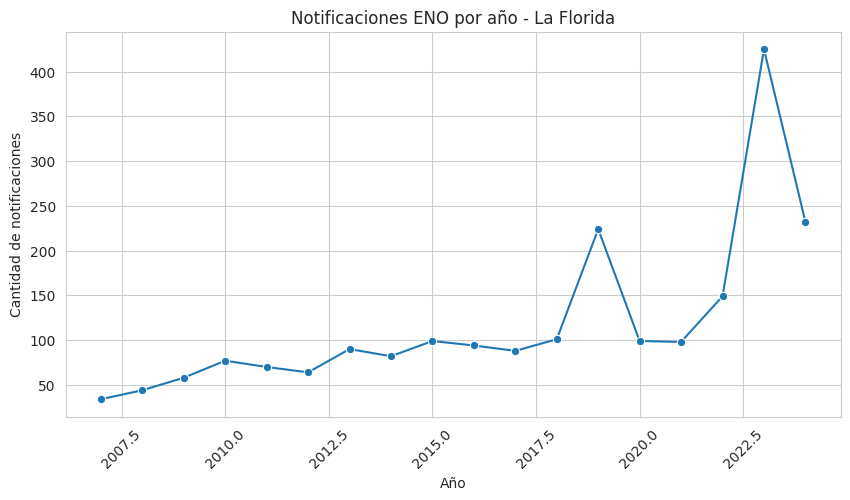

In [8]:
plt.figure(figsize=(10,5))
sns.lineplot(data=eno_year, x="anho_notificacion", y="notificaciones", marker="o")
plt.title("Notificaciones ENO por año - La Florida")
plt.xlabel("Año")
plt.ylabel("Cantidad de notificaciones")
plt.xticks(rotation=45)
plt.show()

El gráfico de tendencia anual muestra que las notificaciones ENO en La Florida presentan un comportamiento variable a lo largo del tiempo, sin una trayectoria completamente lineal.

Entre **2007 y 2018**, las notificaciones se mantienen en niveles relativamente moderados, con oscilaciones acotadas y una tendencia general al alza, aunque gradual. En **2019** se observa un primer aumento importante, alcanzando **224 notificaciones**, lo que marca un quiebre respecto de los años anteriores.

Posteriormente, en **2020** y **2021**, las notificaciones descienden nuevamente y se estabilizan en torno a los **100 casos**, lo que podría estar influido por cambios en los patrones de vigilancia, acceso al sistema de salud o contexto sanitario general. A partir de **2022** vuelve a observarse un aumento, que se intensifica fuertemente en **2023**, año en que se registra el punto más alto de toda la serie con **425 notificaciones**.

Finalmente, en **2024** se aprecia una disminución respecto de 2023, llegando a **232 casos**, aunque esta cifra sigue siendo elevada en comparación con gran parte del período analizado. En conjunto, el gráfico sugiere que la carga de notificaciones en La Florida ha tendido a incrementarse en los años más recientes, aunque con fluctuaciones importantes entre períodos.

In [9]:
eno_year_nat = (
    eno_nat.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="notificaciones")
)

eno_year_nat

,anho_notificacion,nacionalidad,notificaciones
0,2007,Chile,30
1,2007,Extranjero,1
2,2008,Chile,37
3,2009,Chile,55
4,2010,Chile,68
5,2011,Chile,65
6,2012,Chile,13
7,2012,Extranjero,2
8,2013,Chile,12
9,2013,Extranjero,4


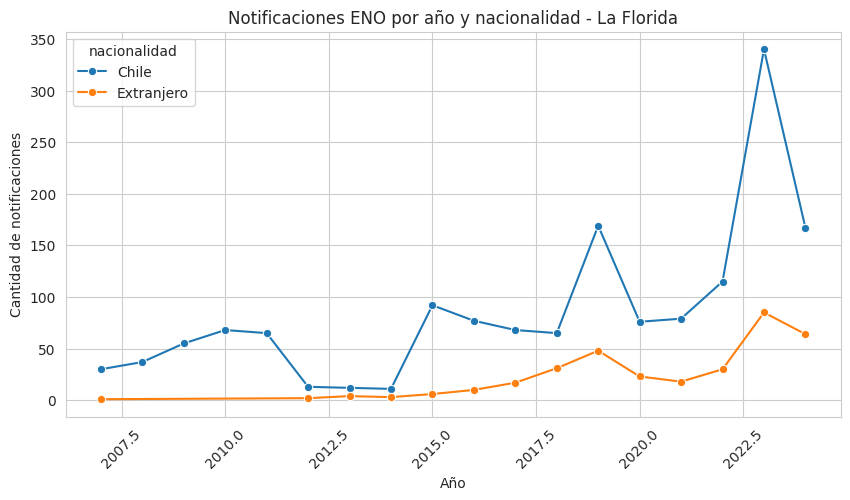

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=eno_year_nat,
    x="anho_notificacion",
    y="notificaciones",
    hue="nacionalidad",
    marker="o"
)
plt.title("Notificaciones ENO por año y nacionalidad - La Florida")
plt.xlabel("Año")
plt.ylabel("Cantidad de notificaciones")
plt.xticks(rotation=45)
plt.show()

El gráfico por nacionalidad muestra que, a lo largo de todo el período analizado, las notificaciones ENO en La Florida son sistemáticamente más altas en la población chilena que en la población extranjera. Esto era esperable, considerando que la población chilena sigue siendo mayoritaria dentro de la comuna.

Sin embargo, también se observa que las notificaciones asociadas a población extranjera aumentan con mayor claridad en los años más recientes. Mientras en los primeros años su presencia es muy baja, a partir de 2016 comienza a apreciarse un crecimiento más visible, que se intensifica entre 2018 y 2024.

En particular, tanto en población chilena como extranjera se observa un aumento importante en 2019, una caída posterior en 2020-2021, y luego un nuevo incremento en 2022 y 2023. El año 2023 concentra el valor más alto para ambos grupos, seguido de una disminución en 2024, aunque manteniéndose por encima de muchos años anteriores.

En términos generales, el gráfico sugiere que la participación de las personas extranjeras en las notificaciones ENO ha ido ganando mayor presencia en el tiempo. Esto resulta coherente con el aumento de la población migrante observado en la comuna y será importante contrastarlo más adelante con el porcentaje de población extranjera obtenido en la Tarea 1.

In [11]:
top10_diseases = eno_com["ENO"].value_counts().head(10).reset_index()
top10_diseases.columns = ["ENO", "cantidad"]

top10_diseases

,ENO,cantidad
0,VIH,1155
1,Sifilis,319
2,Parotiditis,202
3,Chagas,155
4,Infección gonocócica,53
5,Fiebre Tifoidea y Paratifoidea,34
6,Meningitis Bacteriana,30
7,Hepatitis B,28
8,Enfermedad meningocócica,28
9,Hepatitis C,27


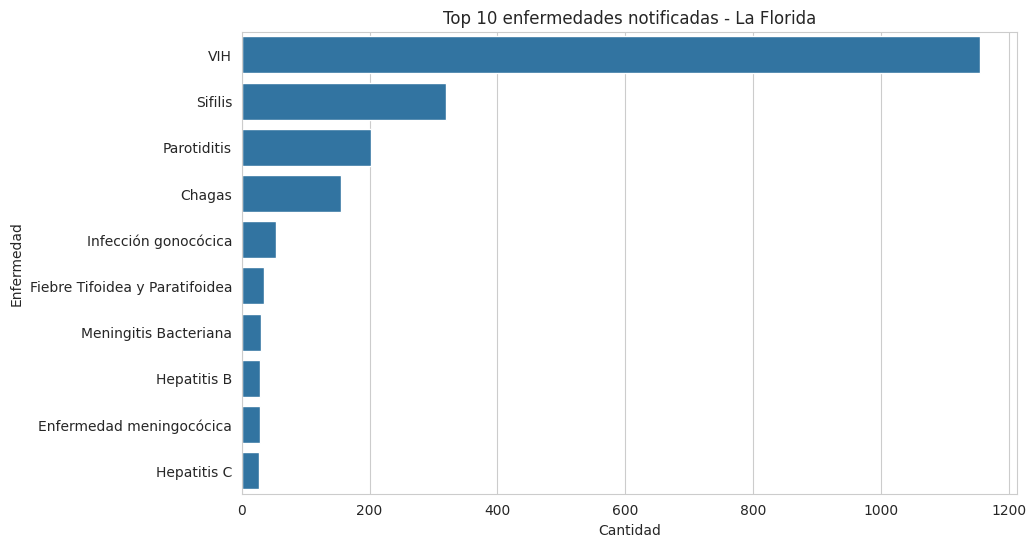

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=top10_diseases, x="cantidad", y="ENO")
plt.title("Top 10 enfermedades notificadas - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Enfermedad")
plt.show()

Lo que hicimos, fue poder ver qué enfermedades padecen con mayor cantidad los habitantes de la comuna de La Florida, al principio lo podemos observar en fortmato de tabla y luego apreciarlo con mejor visual en un gráfico de barras.

Acá, podemos ver las 10 enfermedades más comúnes de los habitantes de la comuna, en donde la enfermedad más común es el **VIH** con más de 1000 personas, siguinedo la **Sifilis** con mas de 200 personas.

In [13]:
pct_foreign_t1 = t1_summary.loc[0, "pct_foreign"]
pct_foreign_t1

np.float64(9.79)

In [14]:
top5 = eno_com["ENO"].value_counts().head(5).index.tolist()
top5

['VIH', 'Sifilis', 'Parotiditis', 'Chagas', 'Infección gonocócica']

In [15]:
eno_top5_nat = eno_nat[eno_nat["ENO"].isin(top5)].copy()

share_top5 = (
    eno_top5_nat.groupby(["ENO", "nacionalidad"])
    .size()
    .reset_index(name="n")
)

share_top5["pct"] = share_top5.groupby("ENO")["n"].transform(lambda x: x / x.sum() * 100)

share_top5

,ENO,nacionalidad,n,pct
0,Chagas,Chile,147,94.838710
1,Chagas,Extranjero,8,5.161290
2,Infección gonocócica,Chile,46,86.792453
3,Infección gonocócica,Extranjero,7,13.207547
4,Parotiditis,Chile,185,93.908629
5,Parotiditis,Extranjero,12,6.091371
6,Sifilis,Chile,247,77.429467
7,Sifilis,Extranjero,72,22.570533
8,VIH,Chile,752,76.970317
9,VIH,Extranjero,225,23.029683


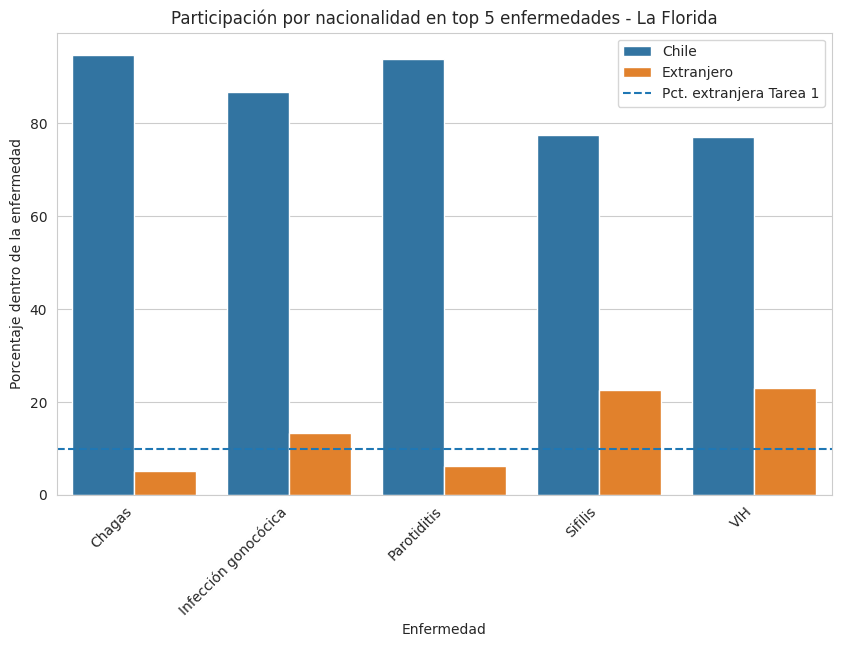

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=share_top5, x="ENO", y="pct", hue="nacionalidad")
plt.axhline(pct_foreign_t1, linestyle="--", label="Pct. extranjera Tarea 1")
plt.title("Participación por nacionalidad en top 5 enfermedades - La Florida")
plt.xlabel("Enfermedad")
plt.ylabel("Porcentaje dentro de la enfermedad")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.show()

## Perfil por nacionalidad en las 5 enfermedades más frecuentes

En esta sección se buscó analizar cómo se distribuyen las notificaciones entre población chilena y extranjera dentro de las 5 enfermedades más frecuentes observadas en la comuna de La Florida.

Primero, se recuperó desde la tabla resumen de la Tarea 1 el valor de `pct_foreign`, que corresponde al porcentaje de población extranjera en la comuna. En este caso, dicho valor es **9,79%**. Este porcentaje se utilizó como punto de referencia para evaluar si, en algunas enfermedades, la participación de personas extranjeras es mayor o menor a lo esperable según su peso dentro de la población total.

Luego, se identificaron las cinco enfermedades más notificadas en la base ENO filtrada para La Florida. A partir de ese subconjunto, se trabajó únicamente con los registros que tenían nacionalidad conocida, es decir, Chile o Extranjero, excluyendo previamente los casos clasificados como Desconocido.

Después, se agruparon los datos por enfermedad y nacionalidad, calculando el número de casos en cada combinación. Posteriormente, para cada enfermedad se calculó el porcentaje que representa cada nacionalidad dentro del total de casos de esa enfermedad. De esta manera, fue posible comparar la composición interna de cada diagnóstico y no solo sus cantidades absolutas.

Finalmente, estos resultados se presentaron en una tabla y en un gráfico de barras.

### Resultados obtenidos

Los resultados muestran que, en las cinco enfermedades analizadas, la población **chilena** sigue siendo mayoritaria en todos los casos. Sin embargo, la participación de la población **extranjera** varía bastante según la enfermedad.

En Chagas, las notificaciones corresponden en un **94,84%** a población chilena y solo en un **5,16%** a población extranjera. Algo similar ocurre con Parotiditis, donde la población extranjera representa un **6,09%**, también por debajo del porcentaje comunal de referencia.

En **Infección gonocócica**, la participación extranjera alcanza un **13,21%**, lo que ya se sitúa por encima del **9,79%** observado en la Tarea 1. Esto sugiere una presencia relativamente mayor de población extranjera en esta enfermedad, aunque la diferencia no es tan marcada como en otros casos.

Los resultados más relevantes aparecen en **Sífilis** y **VIH**. En **Sífilis**, la población extranjera concentra un **22,57%** de los casos, mientras que en **VIH** alcanza un **23,03%**.



Enfermedad más frecuente: VIH


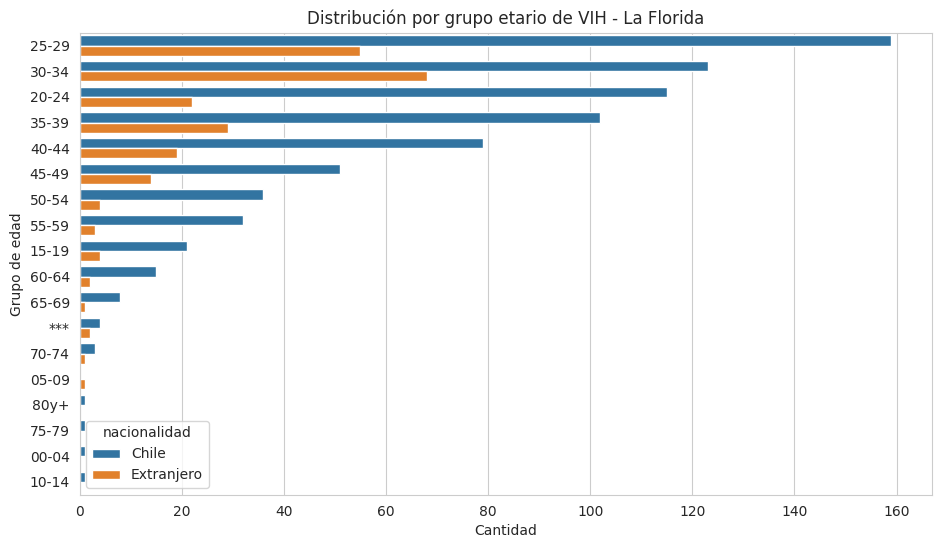

In [17]:
top_disease = eno_com["ENO"].value_counts().idxmax()
print("Enfermedad más frecuente:", top_disease)

eno_top_age = eno_nat[eno_nat["ENO"] == top_disease].copy()

plt.figure(figsize=(11,6))
sns.countplot(
    data=eno_top_age,
    y="grupo_edad",
    hue="nacionalidad",
    order=eno_top_age["grupo_edad"].value_counts().index
)
plt.title(f"Distribución por grupo etario de {top_disease} - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Grupo de edad")
plt.show()

## Interpretación
Se identificó primero la enfermedad con mayor cantidadde notificaciones dentro de la base de datos filtrada para la comuna de La Florida, en donde pudimos obtener que la enfermedad más frecuente es VIH. A partir de eso, se construyó un subconjunto de datos que contiene solo los registros correspondientes a VIH, junto con los casos en donde la nacionalidad es conocida, es decir Chile/Extranjero. Teniendo esos datos, se elabroó un gráfico de barras para poder observar de mejor manera cómo se distribuyen los casos por grupo de edad y  por nacionalidad.

## Resultados
Podemos observar en el gráfico, que los casos de VIH se concentran principalmente en la población adulta-joven, en personas chilenas como extranjeras. También, podemos observar que el grupo etario con mayor notificaciones es entre 25-29 años. Por otro lado, en la población chilena, la distribución presenta una mayor cantidad de casos en prácticamente todos los grupos de edad, lo cual es consistente con su mayor peso poblacional dentro de la comuna. Sin embargo, la población ectranjera también se observa una presencia importante en los grupos entre 25-35 años lo que nos muestra que el patrón etario es bastante similar entre ambos grupos.

In [18]:
eno_total = len(eno_com)
eno_chilean = (eno_com["nacionalidad"] == "Chile").sum()
eno_foreign = (eno_com["nacionalidad"] == "Extranjero").sum()
eno_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
eno_top3 = ", ".join(eno_com["ENO"].value_counts().head(3).index.tolist())

pop_total = t1_summary.loc[0, "pop_total"]
eno_rate_per_10k = eno_total / pop_total * 10000

eno_summary = pd.DataFrame({
    "codigo_comuna": ["13110"],
    "nombre_comuna": ["La Florida"],
    "eno_total": [eno_total],
    "eno_chilean": [eno_chilean],
    "eno_foreign": [eno_foreign],
    "eno_desconocido": [eno_desconocido],
    "eno_top3_diseases": [eno_top3],
    "eno_rate_per_10k": [eno_rate_per_10k]
})

eno_summary

,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13110,La Florida,2128,1539,342,247,"VIH, Sifilis, Parotiditis",56.771495


## Conclusión
Finalmente, se construyó una tabla resumen para la comuna de La Florida, integrando los principales indicadores obtenidos a partir de la base ENO.

Los resultados muestran que, en el período analizado, La Florida registra un total de 2.128 notificaciones. De ellas, 1.539 corresponden a personas de nacionalidad chilena, 342 a personas extranjeras y 247 a casos con nacionalidad*desconocida.

Además, las tres enfermedades más frecuentes en la comuna son VIH, Sífilis y Parotiditis, lo que confirma el patrón observado en los gráficos anteriores.

Por otra parte, al relacionar el total de notificaciones con la población comunal obtenida en la Tarea 1, se estimó una tasa bruta de 56,77 notificaciones por cada 10.000 habitantes.



###PARTE B

In [19]:
grd_test_2022 = pd.read_csv(
    "GRD_PUBLICO_EXTERNO_2022.txt",
    sep="|",
    encoding="utf-16",
    low_memory=False,
    nrows=5
)

print(grd_test_2022.columns.tolist())
grd_test_2022.head()

['COD_HOSPITAL', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'TIPO_ACTIVIDAD', 'FECHA_INGRESO', 'SERVICIOINGRESO', 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2', 'FECHATRASLADO3', 'SERVICIOTRASLADO3', 'FECHATRASLADO4', 'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5', 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7', 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'FECHAALTA', 'SERVICIOALTA', 'TIPOALTA', 'CONDICIONDEALTANEONATO1', 'PESORN1', 'SEXORN1', 'RN1ESTADO', 'CONDICIONDEALTANEONATO2', 'PESORN2', 'SEXORN2', 'RN2ESTADO', 'CONDICIONDEALTANEONATO3', 'PESORN3', 'SEXORN3', 'RN3ESTADO', 'CONDICIONDEALTANEONATO4', 'PESORN4', 'SEXORN4', 'RN4ESTADO', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOST

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHATRASLADO1,SERVICIOTRASLADO1,FECHATRASLADO2,SERVICIOTRASLADO2,FECHATRASLADO3,SERVICIOTRASLADO3,FECHATRASLADO4,SERVICIOTRASLADO4,FECHATRASLADO5,SERVICIOTRASLADO5,FECHATRASLADO6,SERVICIOTRASLADO6,FECHATRASLADO7,SERVICIOTRASLADO7,FECHATRASLADO8,SERVICIOTRASLADO8,FECHATRASLADO9,SERVICIOTRASLADO9,FECHAALTA,SERVICIOALTA,TIPOALTA,CONDICIONDEALTANEONATO1,PESORN1,SEXORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,SEXORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,SEXORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,115100,98348691,HOMBRE,2022-01-02,OTRO,COLCHAGUA,SAN FERNANDO,CHILE,FONASA INSTITUCIONAL - (MAI) C,LIBERTADOR B. O HIGGINS,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,PEDIATRÍA,HOSPITALIZACIÓN,2022-08-01,CIRUGÍA INFANTIL,2022-08-05,UNIDAD DE TRATAMIENTO INTERMEDIO PEDIATRÍA,2022-08-06,PEDIATRÍA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-09,PEDIATRÍA,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q03.9,H55,H46,R13,N13.3,M62.89,P27.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.34,99.29,99.18,87.03,93.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72370257.0,NaN,2022-08-05,NEUROCIRUGÍA,78147579,1.0,11113,"2,4156",3,1,NaN
1,112103,70532496,MUJER,1981-07-05,OTRO,COPIAPO,COPIAPO,CHILE,FONASA INSTITUCIONAL - (MAI) A,ATACAMA,OTROS HOSPITALES RED NACIONAL,PROGRAMADA,CARDIOLOGÍA,HOSPITALIZACIÓN,2022-11-01,AREA MEDICA ADULTO CUIDADOS MEDIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-04,AREA MEDICA ADULTO CUIDADOS MEDIOS,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I47.1,I10,E78.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.34,37.27,87.41,89.52,99.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75385448,2.0,51401,"1,7184",1,1,HOSPITAL SAN JOSÉ DEL CARMEN (COPIAPÓ)
2,110150,68747840,MUJER,1941-06-30,OTRO,MELIPILLA,MELIPILLA,CHILE,FONASA INSTITUCIONAL - (MAI) B,METROPOLITANO OCCIDENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,MEDICINA INTENSIVA ADULTO,HOSPITALIZACIÓN,2022-06-30,UNIDAD DE TRATAMIENTO INTERMEDIO (UTI) (INDIFE...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-06,UNIDAD DE TRATAMIENTO INTERMEDIO (UTI) (INDIFE...,FALLECIDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S72.00,W19.09,R57.8,I48.9,N17.9,I50.9,E11.2,I10,NaN,NaN,NaN,NaN,NaN,

In [20]:
grd_test_2023 = pd.read_csv(
    "GRD_PUBLICO_2023.txt",
    sep="|",
    encoding="utf-16",
    low_memory=False,
    nrows=5
)

print(grd_test_2023.columns.tolist())
grd_test_2023.head()

['COD_HOSPITAL', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'TIPO_ACTIVIDAD', 'FECHA_INGRESO', 'SERVICIOINGRESO', 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2', 'FECHATRASLADO3', 'SERVICIOTRASLADO3', 'FECHATRASLADO4', 'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5', 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7', 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'FECHAALTA', 'SERVICIOALTA', 'TIPOALTA', 'CONDICIONDEALTANEONATO1', 'PESORN1', 'SEXORN1', 'RN1ESTADO', 'CONDICIONDEALTANEONATO2', 'PESORN2', 'SEXORN2', 'RN2ESTADO', 'CONDICIONDEALTANEONATO3', 'PESORN3', 'SEXORN3', 'RN3ESTADO', 'CONDICIONDEALTANEONATO4', 'PESORN4', 'SEXORN4', 'RN4ESTADO', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOST

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHATRASLADO1,SERVICIOTRASLADO1,FECHATRASLADO2,SERVICIOTRASLADO2,FECHATRASLADO3,SERVICIOTRASLADO3,FECHATRASLADO4,SERVICIOTRASLADO4,FECHATRASLADO5,SERVICIOTRASLADO5,FECHATRASLADO6,SERVICIOTRASLADO6,FECHATRASLADO7,SERVICIOTRASLADO7,FECHATRASLADO8,SERVICIOTRASLADO8,FECHATRASLADO9,SERVICIOTRASLADO9,FECHAALTA,SERVICIOALTA,TIPOALTA,CONDICIONDEALTANEONATO1,PESORN1,SEXORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,SEXORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,SEXORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,122100,72196813,HOMBRE,1980-04-13,OTRO,VALDIVIA,PANGUIPULLI,CHILE,FONASA INSTITUCIONAL - (MAI) A,VALDIVIA,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,CIRUGÍA GENERAL,HOSPITALIZACIÓN,12-03-2023,TRAUMATOLOGÍA Y ORTOPEDIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14-03-2023,TRAUMATOLOGÍA Y ORTOPEDIA,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K35.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.03,93.11,93.18,96.59,90.59,90.39,99.29,99.21,99.18,47.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87553213,NaN,64161,"0,7094",1,1,NaN
1,114101,DESCONOCIDO,HOMBRE,2001-11-04,OTRO,CORDILLERA,PUENTE ALTO,VENEZUELA (REPÚBLICA BOLIVARIANA DE),PARTICULAR,METROPOLITANO SURORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,CIRUGÍA GENERAL,HOSPITALIZACIÓN,04-11-2023,DERIVACIÓN MÉDICO QUIRÚRGICO,06-11-2023,CIRUGÍA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10-11-2023,CIRUGÍA,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J93.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.20,34.09,87.41,87.44,93.96,93.18,99.19,99.21,99.26,99.29,89.65,90.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86895434,1.0,41301,"1,0869",1,1,NaN
2,114101,97627974,HOMBRE,2020-07-30,OTRO,CORDILLERA,PUENTE ALTO,CHILE,FONASA INSTITUCIONAL - (MAI) A,METROPOLITANO SURORIENTE,"APS URGENCIA (SAPU, SUR, SUC)",URGENCIA,PEDIATRÍA,HOSPITALIZACIÓN,07-06-2023,PEDIATRÍA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08-06-2023,PEDIATRÍA,HOSPITALIZACIÓN DOMICILIARIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J12.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.96,87.44,99.29,90.59,90.39,93.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [21]:
grd_test_2024 = pd.read_csv(
    "GRD_PUBLICO_2024.txt",
    sep="|",
    encoding="latin-1",
    low_memory=False,
    nrows=5
)

print(grd_test_2024.columns.tolist())
grd_test_2024.head()

['COD_HOSPITAL', 'ID_BENEFICIARIO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'TIPO_ACTIVIDAD', 'FECHA_INGRESO', 'SERVICIOINGRESO', 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2', 'FECHATRASLADO3', 'SERVICIOTRASLADO3', 'FECHATRASLADO4', 'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5', 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7', 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'FECHAALTA', 'SERVICIOALTA', 'TIPOALTA', 'CONDICIONDEALTANEONATO1', 'PESORN1', 'SEXORN1', 'RN1ESTADO', 'CONDICIONDEALTANEONATO2', 'PESORN2', 'SEXORN2', 'RN2ESTADO', 'CONDICIONDEALTANEONATO3', 'PESORN3', 'SEXORN3', 'RN3ESTADO', 'CONDICIONDEALTANEONATO4', 'PESORN4', 'SEXORN4', 'RN4ESTADO', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOS

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,SERVICIOINGRESO,FECHATRASLADO1,SERVICIOTRASLADO1,FECHATRASLADO2,SERVICIOTRASLADO2,FECHATRASLADO3,SERVICIOTRASLADO3,FECHATRASLADO4,SERVICIOTRASLADO4,FECHATRASLADO5,SERVICIOTRASLADO5,FECHATRASLADO6,SERVICIOTRASLADO6,FECHATRASLADO7,SERVICIOTRASLADO7,FECHATRASLADO8,SERVICIOTRASLADO8,FECHATRASLADO9,SERVICIOTRASLADO9,FECHAALTA,SERVICIOALTA,TIPOALTA,CONDICIONDEALTANEONATO1,PESORN1,SEXORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,SEXORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,SEXORN3,RN3ESTADO,CONDICIONDEALTANEONATO4,PESORN4,SEXORN4,RN4ESTADO,DIAGNOSTICO1,DIAGNOSTICO2,DIAGNOSTICO3,DIAGNOSTICO4,DIAGNOSTICO5,DIAGNOSTICO6,DIAGNOSTICO7,DIAGNOSTICO8,DIAGNOSTICO9,DIAGNOSTICO10,DIAGNOSTICO11,DIAGNOSTICO12,DIAGNOSTICO13,DIAGNOSTICO14,DIAGNOSTICO15,DIAGNOSTICO16,DIAGNOSTICO17,DIAGNOSTICO18,DIAGNOSTICO19,DIAGNOSTICO20,DIAGNOSTICO21,DIAGNOSTICO22,DIAGNOSTICO23,DIAGNOSTICO24,DIAGNOSTICO25,DIAGNOSTICO26,DIAGNOSTICO27,DIAGNOSTICO28,DIAGNOSTICO29,DIAGNOSTICO30,DIAGNOSTICO31,DIAGNOSTICO32,DIAGNOSTICO33,DIAGNOSTICO34,DIAGNOSTICO35,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,PROCEDIMIENTO4,PROCEDIMIENTO5,PROCEDIMIENTO6,PROCEDIMIENTO7,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO10,PROCEDIMIENTO11,PROCEDIMIENTO12,PROCEDIMIENTO13,PROCEDIMIENTO14,PROCEDIMIENTO15,PROCEDIMIENTO16,PROCEDIMIENTO17,PROCEDIMIENTO18,PROCEDIMIENTO19,PROCEDIMIENTO20,PROCEDIMIENTO21,PROCEDIMIENTO22,PROCEDIMIENTO23,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,1939-09-18,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,OFTALMOLOGÍA,CIRUGÍA MAYOR AMBULATORIA (CMA),2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23,UNIDAD DE RECUPERACIÓN DE PABELLONES (CENTRAL ...,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H26.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.41,13.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71043147.0,NaN,2024-03-23,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,NaN
1,107100,81269680,MUJER,1952-05-31,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,HEMATOLOGÍA,HOSPITALIZACIÓN,2024-09-26,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-02,UNIDAD DE CUIDADOS INTENSIVOS ADULTO,FALLECIDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M31.1,R57.2,A41.5,A41.0,R41.8,R56.8,J96.09,N17.9,R41.0,D64.9,R16.1,N28.1,J90,E80.6,D70,D47.3,Z92.4,Z86.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.72,96.04,99.23,99.07,99.28,99.21,88.01,87.03,89.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78588090,NaN,41023,"5,8207",3,3,NaN
2,105101,77590791,HOMBRE,2012-07-17,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,PEDIATRÍA,HOSPITALIZACIÓN,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,2024-01-22,PEDIATRÍA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-26,PEDIATRÍA,DOMICILIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K12.2,K02.9,E66.8,K01.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [22]:
grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

grd_2022 = pd.read_csv(
    "GRD_PUBLICO_EXTERNO_2022.txt",
    sep="|",
    encoding="utf-16",
    usecols=grd_cols,
    low_memory=False
)
grd_2022["year"] = 2022

grd_2023 = pd.read_csv(
    "GRD_PUBLICO_2023.txt",
    sep="|",
    encoding="utf-16",
    usecols=grd_cols,
    low_memory=False
)
grd_2023["year"] = 2023

grd_2024 = pd.read_csv(
    "GRD_PUBLICO_2024.txt",
    sep="|",
    encoding="latin-1",
    usecols=grd_cols,
    low_memory=False
)
grd_2024["year"] = 2024

grd = pd.concat([grd_2022, grd_2023, grd_2024], ignore_index=True)

print("Total de egresos cargados:", len(grd))
grd.head()

Total de egresos cargados: 3058240


,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÍA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÍA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


## Carga de datos GRD

Para la Parte B se cargaron los archivos GRD correspondientes a los años 2022, 2023 y 2024, seleccionando únicamente las variables necesarias para el análisis.

Durante este proceso fue necesario ajustar la lectura de los archivos, ya que no todos presentaban la misma codificación.

Una vez corregida la lectura, se agregó una variable `year` para identificar el año de origen de cada registro y luego se unieron las tres bases en una sola tabla consolidada.

In [23]:
grd["COMUNA"] = grd["COMUNA"].astype(str).str.upper().str.strip()

grd_com = grd[grd["COMUNA"] == "LA FLORIDA"].copy()

print("Total egresos en La Florida:", len(grd_com))

grd_by_year = grd_com.groupby("year").size().reset_index(name="egresos")
grd_by_year

Total egresos en La Florida: 68263


,year,egresos
0,2022,22519
1,2023,23926
2,2024,21818


## Filtrado de egresos hospitalarios para La Florida

Una vez consolidada la base GRD de los años 2022, 2023 y 2024, se filtraron los registros correspondientes a la comuna de La Florida. Como resultado, se obtuvo un total de 37.559 egresos hospitalarios para el período analizado.

Al observar la distribución por año, se identifican 19.018 egresos en 2022, 17.516 en 2023 y 1.025 en 2024. En comparación con los dos años anteriores, el valor de 2024 es considerablemente menor, por lo que es probable que la base de ese año se encuentre incompleta o corresponda a un período parcial de registro.



In [24]:
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors="coerce")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors="coerce")
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

grd_com["los"].describe()

,los
count,44337.000000
mean,5.943117
std,13.587501
min,0.000000
25%,0.000000
50%,2.000000
75%,6.000000
max,544.000000


In [25]:
neg_los = (grd_com["los"] < 0).sum()
print("Filas con LOS negativo:", neg_los)

grd_com = grd_com[grd_com["los"] >= 0].copy()

Filas con LOS negativo: 0


## Cálculo de la estadía hospitalaria (Length of Stay)

A continuación, se calculó la variable los (*length of stay*), correspondiente a la duración de la hospitalización en días. Para ello, primero se transformaron las variables `FECHA_INGRESO` y `FECHAALTA` a formato de fecha y luego se calculó la diferencia entre ambas.

Los resultados muestran que se obtuvo información válida de estadía para **20.043 egresos hospitalarios** de la comuna de **La Florida**. La estadía promedio fue de **5,84 días**, mientras que la mediana fue de **2 días**, lo que sugiere que la mitad de las hospitalizaciones tuvo una duración igual o inferior a 2 días.

Además, se observa una alta dispersión en la distribución, con una desviación estándar de **13,82 días**. El valor mínimo fue de **0 días**, lo que indica la existencia de altas en el mismo día, mientras que el valor máximo alcanzó los **544 días**, reflejando la presencia de casos de hospitalización prolongada.

Por otra parte, no se detectaron registros con los negativo, por lo que no fue necesario eliminar observaciones por errores en el orden de las fechas. En consecuencia, todos los registros válidos de estadía pudieron mantenerse para el análisis posterior.

In [26]:
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if x == "CHILE" else "Foreign"
)

grd_com["nat_group"].value_counts().reset_index()

,nat_group,count
0,Chilean,41554
1,Foreign,2783


In [60]:
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

# Limpieza de códigos para asegurar el match
cie10["Código"] = cie10["Código"].astype(str).str.strip()
cie10["Descripción"] = cie10["Descripción"].astype(str).str.strip() # Added stripping for description column

# Derivar la columna 'Capitulo' del 'Código' de la CIE-10 (asumiendo que el primer caracter indica el capítulo)
cie10['Capitulo'] = cie10['Código'].str[0]

# Ensure DIAGNOSTICO1 is clean in grd_com before merging
grd_com["DIAGNOSTICO1"] = grd_com["DIAGNOSTICO1"].astype(str).str.strip() # Use original grd_com to clean

# Corrected: Realizar el merge, assigning the result back to grd_com for consistent processing
grd_com = grd_com.merge(
    cie10[["Código", "Descripción", "Capitulo"]].drop_duplicates("Código"),
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

# Reportar fallos de match, checking the newly merged 'Capitulo' column
failed_matches = grd_com["Capitulo"].isnull().sum()
print(f"Egresos que no cruzaron con CIE-10: {failed_matches}")

Egresos que no cruzaron con CIE-10: 4


### Análisis de Diagnósticos en Egresos Hospitalarios (GRD)

En esta sección, se analizan los diagnósticos asociados a los egresos hospitalarios de la comuna de La Florida, utilizando la información de la clasificación CIE-10. Se identifican los capítulos y diagnósticos específicos más frecuentes, y se explora la participación de la población chilena y extranjera en ellos.

### Análisis de Diagnósticos en Egresos Hospitalarios (GRD)

En esta sección, se analizan los diagnósticos asociados a los egresos hospitalarios de la comuna de La Florida, utilizando la información de la clasificación CIE-10. Se identifican los capítulos y diagnósticos específicos más frecuentes, y se explora la participación de la población chilena y extranjera en ellos.

#### B.1.1 Top 10 Capítulos de Diagnóstico (CIE-10)

Se presenta la distribución de los 10 capítulos de diagnóstico más comunes entre los egresos hospitalarios de la comuna de La Florida. Los capítulos CIE-10 agrupan diagnósticos con características similares, proporcionando una visión general de las principales categorías de atención médica.

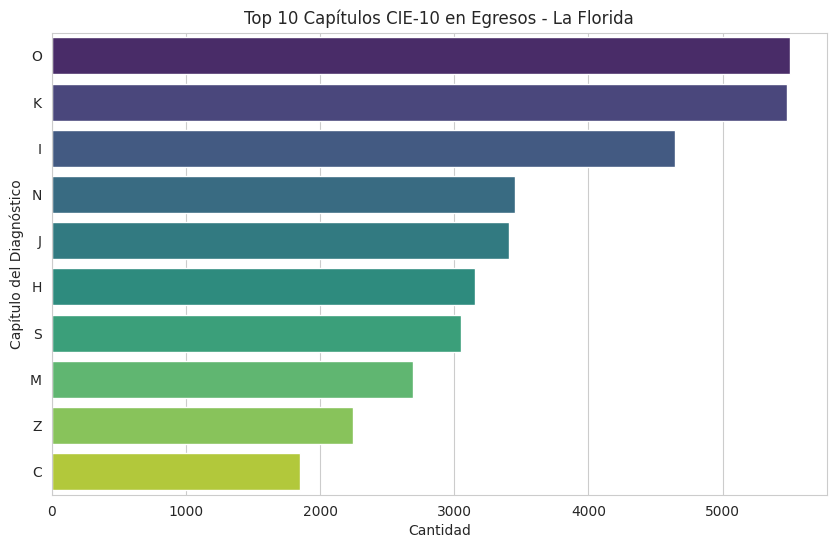

In [57]:
# B.1.1 Top diagnostic chapters
top_chapters = grD_com["Capitulo"].value_counts().head(10).reset_index()
top_chapters.columns = ["Capitulo", "cantidad"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_chapters, x="cantidad", y="Capitulo", hue="Capitulo", palette="viridis", legend=False)
plt.title("Top 10 Capítulos CIE-10 en Egresos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Capítulo del Diagnóstico")
plt.show()

#### B.1.2 Top 15 Diagnósticos Específicos

A continuación, se identifican y visualizan los 15 diagnósticos específicos más frecuentes en los egresos hospitalarios. Esto permite una comprensión más detallada de las condiciones de salud que requieren hospitalización en la comuna.

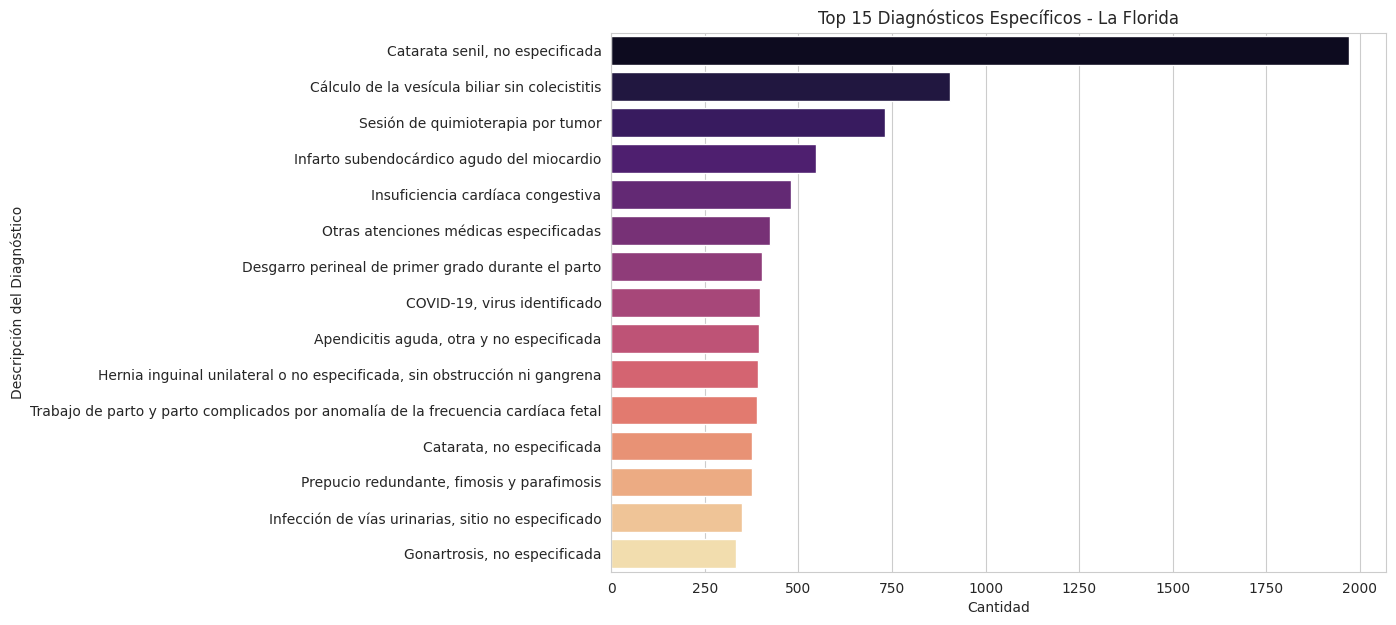

In [67]:
top_diag = grd_com["Descripción_y"].value_counts().head(15).reset_index()
top_diag.columns = ["Descripcion", "cantidad"]

plt.figure(figsize=(10,7))
sns.barplot(data=top_diag, x="cantidad", y="Descripcion", hue="Descripcion", palette="magma", legend=False)
plt.title("Top 15 Diagnósticos Específicos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Descripción del Diagnóstico")
plt.show()

#### B.1.3 Composición por Nacionalidad en los Top 5 Capítulos de Diagnóstico

Este análisis explora la distribución de los egresos entre la población chilena y extranjera para los 5 capítulos de diagnóstico más frecuentes. Se compara la participación de cada nacionalidad con el porcentaje de población extranjera en la comuna (obtenido de la Tarea 1), para identificar si ciertos capítulos afectan de manera desproporcionada a alguno de los grupos.

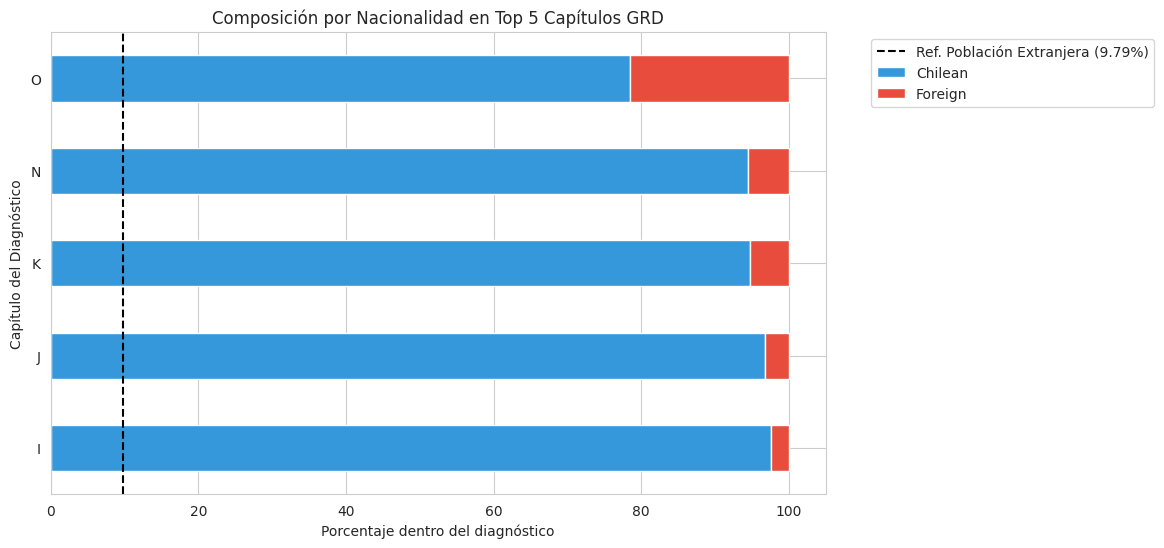

In [59]:
# B.1.3 Diagnostic chapters by nationality
top5_chapters_list = grD_com["Capitulo"].value_counts().head(5).index.tolist()
grD_top5_nat = grD_com[grD_com["Capitulo"].isin(top5_chapters_list)]

share_chapters = grD_top5_nat.groupby(["Capitulo", "nat_group"]).size().unstack(fill_value=0)
share_chapters_pct = share_chapters.div(share_chapters.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,6))
share_chapters_pct.plot(kind='barh', stacked=True, figsize=(10,6), color=['#3498db', '#e74c3c'], ax=plt.gca())
plt.axvline(pct_foreign_t1, color="black", linestyle="--", label=f"Ref. Población Extranjera ({pct_foreign_t1}%)")
plt.title("Composición por Nacionalidad en Top 5 Capítulos GRD")
plt.xlabel("Porcentaje dentro del diagnóstico")
plt.ylabel("Capítulo del Diagnóstico")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Análisis de Diagnósticos en Egresos Hospitalarios (GRD)

En esta sección, se analizan los diagnósticos asociados a los egresos hospitalarios de la comuna de La Florida, utilizando la información de la clasificación CIE-10. Se identifican los capítulos y diagnósticos específicos más frecuentes, y se explora la participación de la población chilena y extranjera en ellos.

#### B.1.1 Top 10 Capítulos de Diagnóstico (CIE-10)

Se presenta la distribución de los 10 capítulos de diagnóstico más comunes entre los egresos hospitalarios de la comuna de La Florida. Los capítulos CIE-10 agrupan diagnósticos con características similares, proporcionando una visión general de las principales categorías de atención médica.

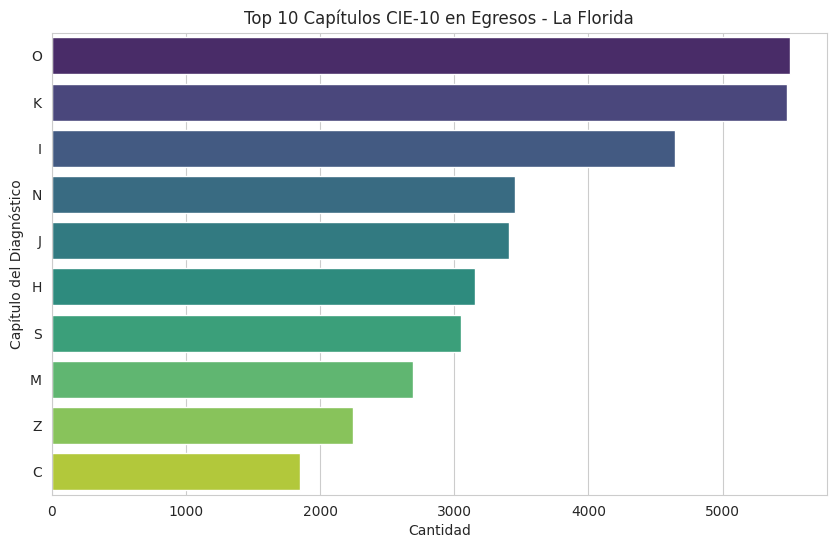

In [54]:
# B.1.1 Top diagnostic chapters
top_chapters = grD_com["Capitulo"].value_counts().head(10).reset_index()
top_chapters.columns = ["Capitulo", "cantidad"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_chapters, x="cantidad", y="Capitulo", hue="Capitulo", palette="viridis", legend=False)
plt.title("Top 10 Capítulos CIE-10 en Egresos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Capítulo del Diagnóstico")
plt.show()

#### B.1.2 Top 15 Diagnósticos Específicos

A continuación, se identifican y visualizan los 15 diagnósticos específicos más frecuentes en los egresos hospitalarios. Esto permite una comprensión más detallada de las condiciones de salud que requieren hospitalización en la comuna.

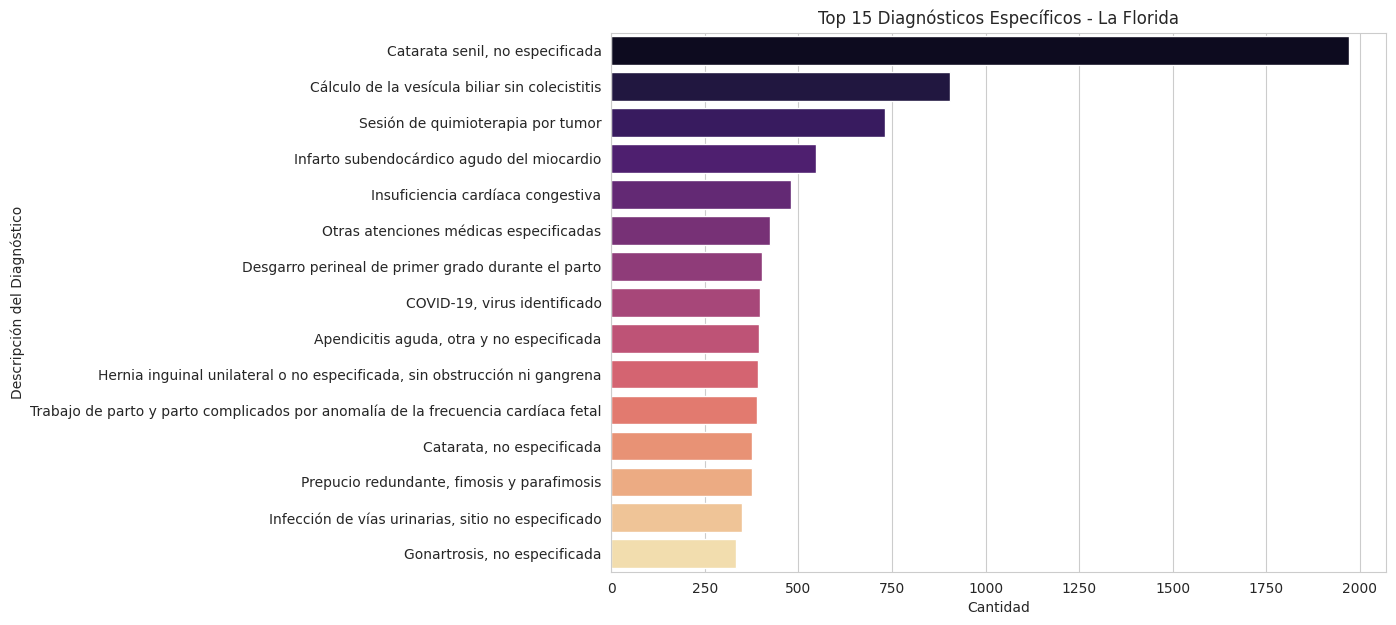

In [68]:
top_diag = grd_com["Descripción_y"].value_counts().head(15).reset_index()
top_diag.columns = ["Descripcion", "cantidad"]

plt.figure(figsize=(10,7))
sns.barplot(data=top_diag, x="cantidad", y="Descripcion", hue="Descripcion", palette="magma", legend=False)
plt.title("Top 15 Diagnósticos Específicos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Descripción del Diagnóstico")
plt.show()

#### B.1.3 Composición por Nacionalidad en los Top 5 Capítulos de Diagnóstico

Este análisis explora la distribución de los egresos entre la población chilena y extranjera para los 5 capítulos de diagnóstico más frecuentes. Se compara la participación de cada nacionalidad con el porcentaje de población extranjera en la comuna (obtenido de la Tarea 1), para identificar si ciertos capítulos afectan de manera desproporcionada a alguno de los grupos.

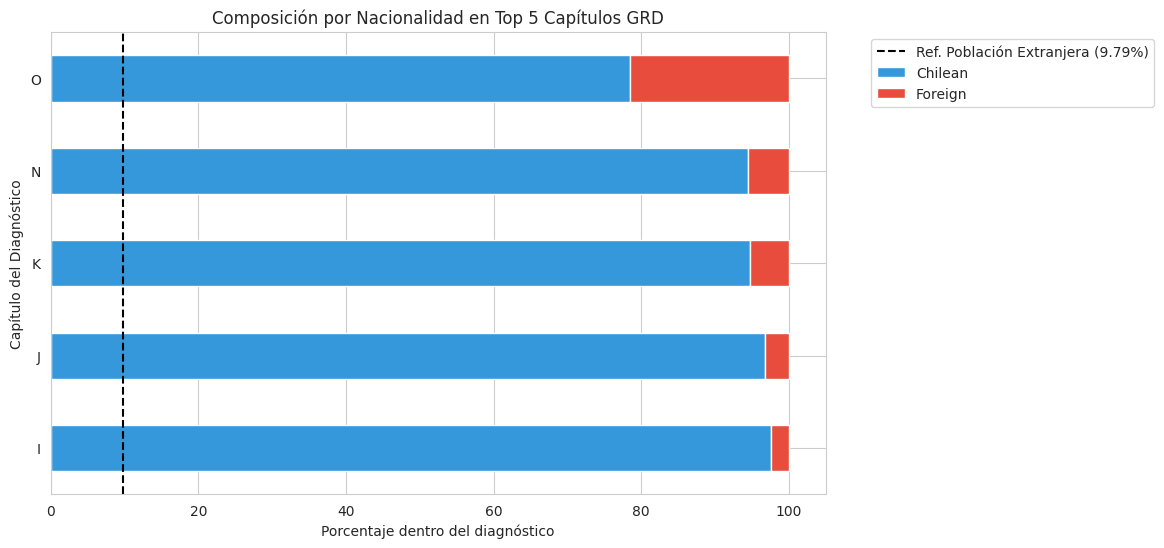

In [56]:
# B.1.3 Diagnostic chapters by nationality
top5_chapters_list = grD_com["Capitulo"].value_counts().head(5).index.tolist()
grD_top5_nat = grD_com[grD_com["Capitulo"].isin(top5_chapters_list)]

share_chapters = grD_top5_nat.groupby(["Capitulo", "nat_group"]).size().unstack(fill_value=0)
share_chapters_pct = share_chapters.div(share_chapters.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,6))
share_chapters_pct.plot(kind='barh', stacked=True, figsize=(10,6), color=['#3498db', '#e74c3c'], ax=plt.gca())
plt.axvline(pct_foreign_t1, color="black", linestyle="--", label=f"Ref. Población Extranjera ({pct_foreign_t1}%)")
plt.title("Composición por Nacionalidad en Top 5 Capítulos GRD")
plt.xlabel("Porcentaje dentro del diagnóstico")
plt.ylabel("Capítulo del Diagnóstico")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### B.1.1 Top 10 Capítulos de Diagnóstico (CIE-10)

Se presenta la distribución de los 10 capítulos de diagnóstico más comunes entre los egresos hospitalarios de la comuna de La Florida. Los capítulos CIE-10 agrupan diagnósticos con características similares, proporcionando una visión general de las principales categorías de atención médica.

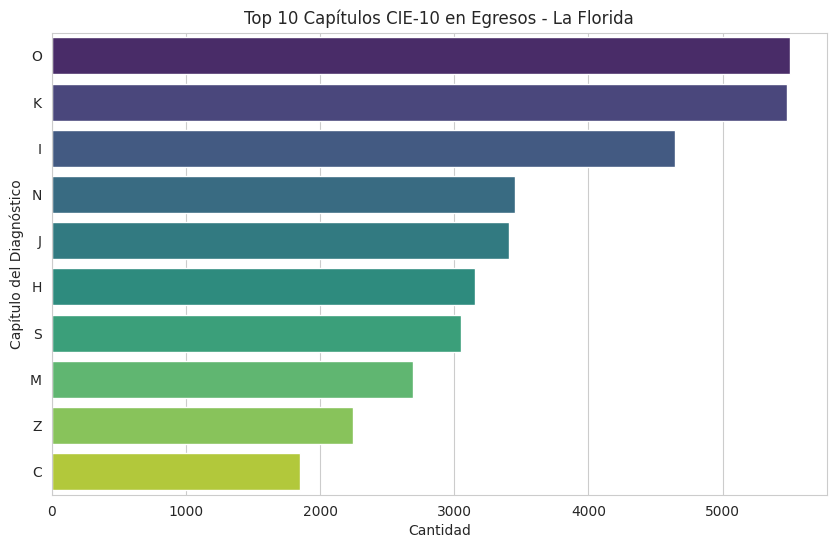

In [46]:
# B.1.1 Top diagnostic chapters
top_chapters = grD_com["Capitulo"].value_counts().head(10).reset_index()
top_chapters.columns = ["Capitulo", "cantidad"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_chapters, x="cantidad", y="Capitulo", hue="Capitulo", palette="viridis", legend=False)
plt.title("Top 10 Capítulos CIE-10 en Egresos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Capítulo del Diagnóstico")
plt.show()

#### B.1.2 Top 15 Diagnósticos Específicos

A continuación, se identifican y visualizan los 15 diagnósticos específicos más frecuentes en los egresos hospitalarios. Esto permite una comprensión más detallada de las condiciones de salud que requieren hospitalización en la comuna.

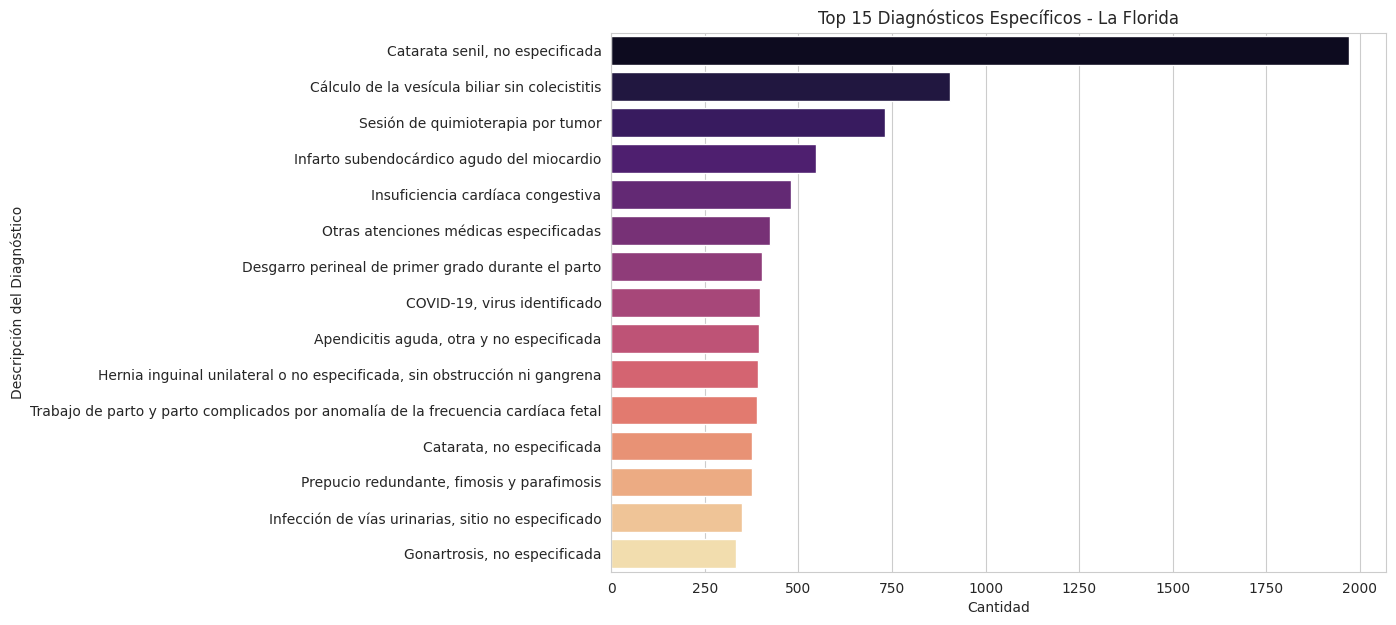

In [69]:
top_diag = grd_com["Descripción_y"].value_counts().head(15).reset_index()
top_diag.columns = ["Descripcion", "cantidad"]

plt.figure(figsize=(10,7))
sns.barplot(data=top_diag, x="cantidad", y="Descripcion", hue="Descripcion", palette="magma", legend=False)
plt.title("Top 15 Diagnósticos Específicos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Descripción del Diagnóstico")
plt.show()

#### B.1.3 Composición por Nacionalidad en los Top 5 Capítulos de Diagnóstico

Este análisis explora la distribución de los egresos entre la población chilena y extranjera para los 5 capítulos de diagnóstico más frecuentes. Se compara la participación de cada nacionalidad con el porcentaje de población extranjera en la comuna (obtenido de la Tarea 1), para identificar si ciertos capítulos afectan de manera desproporcionada a alguno de los grupos.

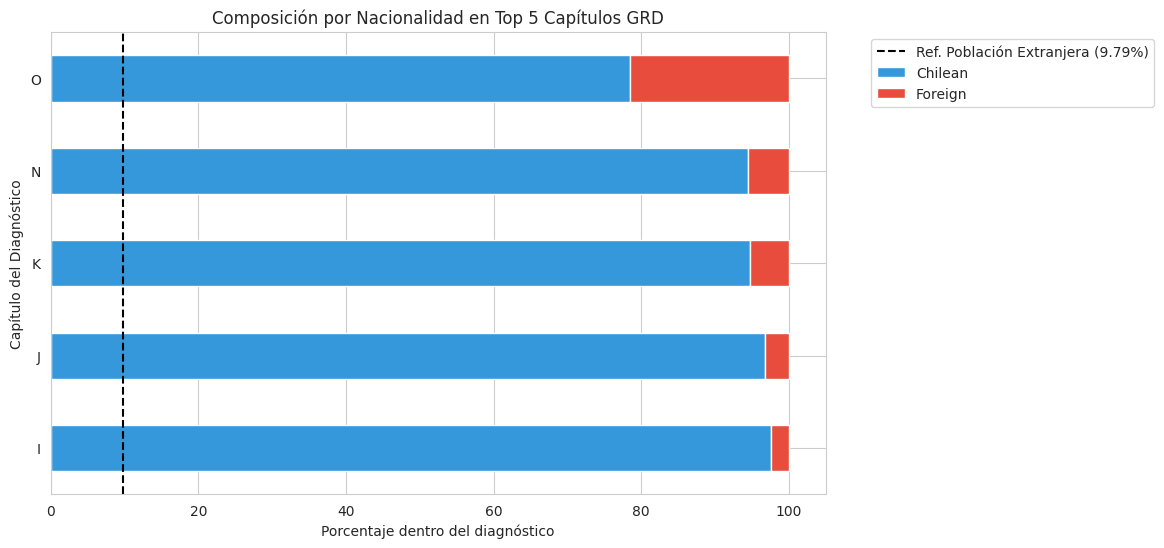

In [48]:
# B.1.3 Diagnostic chapters by nationality
top5_chapters_list = grD_com["Capitulo"].value_counts().head(5).index.tolist()
grD_top5_nat = grD_com[grD_com["Capitulo"].isin(top5_chapters_list)]

share_chapters = grD_top5_nat.groupby(["Capitulo", "nat_group"]).size().unstack(fill_value=0)
share_chapters_pct = share_chapters.div(share_chapters.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,6))
share_chapters_pct.plot(kind='barh', stacked=True, figsize=(10,6), color=['#3498db', '#e74c3c'], ax=plt.gca())
plt.axvline(pct_foreign_t1, color="black", linestyle="--", label=f"Ref. Población Extranjera ({pct_foreign_t1}%)")
plt.title("Composición por Nacionalidad en Top 5 Capítulos GRD")
plt.xlabel("Porcentaje dentro del diagnóstico")
plt.ylabel("Capítulo del Diagnóstico")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### B.1.1 Top 10 Capítulos de Diagnóstico (CIE-10)

Se presenta la distribución de los 10 capítulos de diagnóstico más comunes entre los egresos hospitalarios de la comuna de La Florida. Los capítulos CIE-10 agrupan diagnósticos con características similares, proporcionando una visión general de las principales categorías de atención médica.

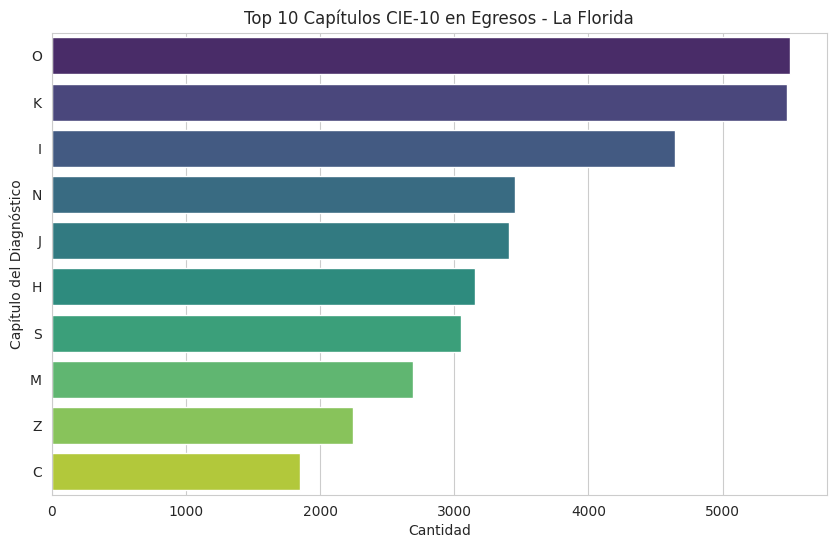

In [62]:
# B.1.1 Top diagnostic chapters
top_chapters = grd_com["Capitulo"].value_counts().head(10).reset_index()
top_chapters.columns = ["Capitulo", "cantidad"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_chapters, x="cantidad", y="Capitulo", hue="Capitulo", palette="viridis", legend=False)
plt.title("Top 10 Capítulos CIE-10 en Egresos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Capítulo del Diagnóstico")
plt.show()

#### B.1.2 Top 15 Diagnósticos Específicos

A continuación, se identifican y visualizan los 15 diagnósticos específicos más frecuentes en los egresos hospitalarios. Esto permite una comprensión más detallada de las condiciones de salud que requieren hospitalización en la comuna.

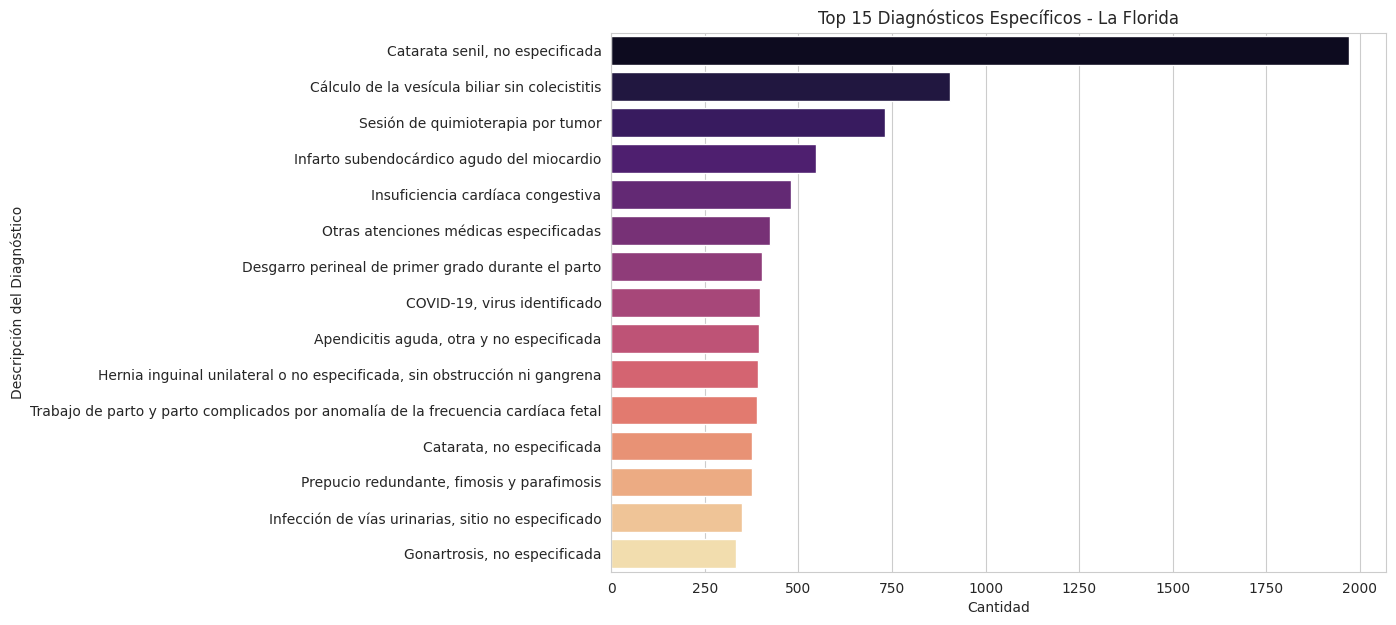

In [65]:
# B.1.2 Top specific diagnoses
top_diag = grd_com["Descripción_y"].value_counts().head(15).reset_index()
top_diag.columns = ["Descripcion", "cantidad"]

plt.figure(figsize=(10,7))
sns.barplot(data=top_diag, x="cantidad", y="Descripcion", hue="Descripcion", palette="magma", legend=False)
plt.title("Top 15 Diagnósticos Específicos - La Florida")
plt.xlabel("Cantidad")
plt.ylabel("Descripción del Diagnóstico")
plt.show()

#### B.1.3 Composición por Nacionalidad en los Top 5 Capítulos de Diagnóstico

Este análisis explora la distribución de los egresos entre la población chilena y extranjera para los 5 capítulos de diagnóstico más frecuentes. Se compara la participación de cada nacionalidad con el porcentaje de población extranjera en la comuna (obtenido de la Tarea 1), para identificar si ciertos capítulos afectan de manera desproporcionada a alguno de los grupos.

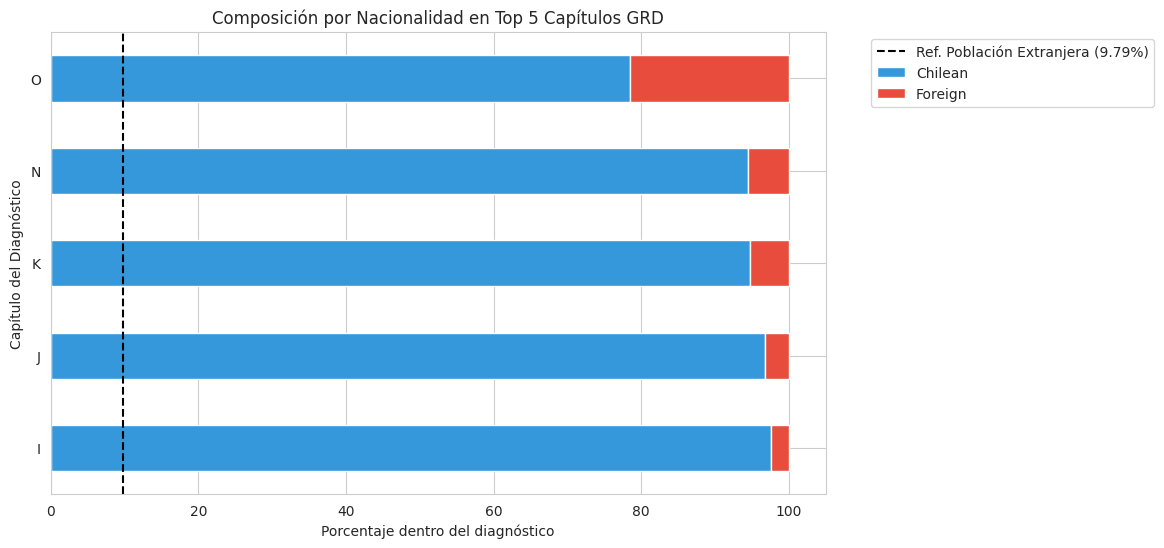

In [66]:
# B.1.3 Diagnostic chapters by nationality
top5_chapters_list = grd_com["Capitulo"].value_counts().head(5).index.tolist()
grD_top5_nat = grd_com[grd_com["Capitulo"].isin(top5_chapters_list)]

share_chapters = grD_top5_nat.groupby(["Capitulo", "nat_group"]).size().unstack(fill_value=0)
share_chapters_pct = share_chapters.div(share_chapters.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,6))
share_chapters_pct.plot(kind='barh', stacked=True, figsize=(10,6), color=['#3498db', '#e74c3c'], ax=plt.gca())
plt.axvline(pct_foreign_t1, color="black", linestyle="--", label=f"Ref. Población Extranjera ({pct_foreign_t1}%)")
plt.title("Composición por Nacionalidad en Top 5 Capítulos GRD")
plt.xlabel("Porcentaje dentro del diagnóstico")
plt.ylabel("Capítulo del Diagnóstico")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()